In [1]:
%load_ext autoreload
%autoreload 2

import sys, os

import importlib
import numpy as np
import pandas as pd
import torch
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score, classification_report

# Detecção robusta do diretório raiz e de src/ para Jupyter, Scripts e Colab
if '__file__' in globals():
    ROOT_DIR = os.path.dirname(os.path.abspath(__file__))
else:
    ROOT_DIR = os.path.abspath(os.getcwd())
    if not os.path.exists(os.path.join(ROOT_DIR, 'src')) and os.path.exists(os.path.join(os.path.dirname(ROOT_DIR), 'src')):
        ROOT_DIR = os.path.dirname(ROOT_DIR)

SRC_DIR = os.path.join(ROOT_DIR, 'src')
for p in (ROOT_DIR, SRC_DIR):
    if p not in sys.path:
        sys.path.insert(0, p)

import config
importlib.reload(config)
from config import (
    PATH_REFERENCIA, PATH_ALVO, PATH_FEATURES_REFERENCIA, PATH_FEATURES_ALVO,
    PATH_SWEEP_REFERENCIA, PATH_SWEEP_ALVO, PATH_LABELS_REFERENCIA, PATH_LABELS_ALVO,
    OUT_BINARIZACAO, OUT_ALINHAMENTO, OUT_TOP_GENES,
    OUT_TREINAMENTO, OUT_HOPFIELD, OUT_RELATORIO,
)

import alinhamento
importlib.reload(alinhamento)

from preprocessing import Binarizador
from alinhamento import (
    LeitorFeatures, AnalisadorSobreposicao, Alinhador, AlinhadorEsparso,
    ValidadorAlinhamento, SelecionadorGenesFrequentes, AnalisadorCobertura,
)
from treinamento import (
    GeradorConjuntoTreinamento, CarregadorDadosFujita,
    ProjetorSWeP, ProjetorSWeePR,
    ExtratorPadroesSubcluster, ModernHopfieldNetwork, AvaliadorHopfield,
    GeradorRelatorio,
)
from treinamento.hopfield_utils import wsort, closervects


SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device('cuda')
    torch.cuda.manual_seed_all(SEED)
    # Garante determinismo em operações CUDA (útil para reprodutibilidade)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f'Dispositivo: {device} ({torch.cuda.get_device_name(0)})')
    print(f'VRAM disponível: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')
else:
    device = torch.device('cpu')
    print(f'Dispositivo: {device} (GPU não disponível)')



Dispositivo: cpu (GPU não disponível)



#### 2. Binarização
 Converte as matrizes de expressão `.h5ad` para formato binário (valores > 0 → 1, zeros → 0). O `Binarizador` detecta automaticamente se o arquivo já existe e pula o processamento nesse caso.

In [2]:
binarizador_ref = Binarizador(path_h5ad=PATH_REFERENCIA, out_dir=OUT_BINARIZACAO)
binarizador_alvo = Binarizador(path_h5ad=PATH_ALVO, out_dir=OUT_BINARIZACAO)

binarizador_ref.binarizar()
binarizador_alvo.binarizar()

print('Referência binarizada em:', binarizador_ref.path_binarizada)
print('Alvo binarizado em:', binarizador_alvo.path_binarizada)


[Binarizador] Arquivo já existe, pulando: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\binarizacao\pan_anotado\matrizBinarizadaM.h5ad
[Binarizador] Arquivo já existe, pulando: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\binarizacao\matriz_anotada_finalM\matrizBinarizadaM.h5ad
Referência binarizada em: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\binarizacao\pan_anotado\matrizBinarizadaM.h5ad
Alvo binarizado em: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\binarizacao\matriz_anotada_finalM\matrizBinarizadaM.h5ad


#### 3. Alinhamento de espaços gênicos ↔️
 Os dois datasets têm espaços gênicos distintos (36 591 genes no Fujita, 32 643 no Mathys, ~30 312 em comum). 
 O alinhamento:
 1. Lê os mapeamentos `gene_name → Ensembl ID` de cada dataset.
 2. Define a ordem canônica dos genes baseada no Fujita (referência).
 3. Realinha ambas as matrizes para esse espaço canônico.
    - Genes ausentes no **Mathys** são preenchidos com `0.5` como sentinela.
 4. Valida que as duas matrizes resultantes têm genes na mesma ordem.

In [3]:
# Passo 1 — Leitura dos arquivos de features
leitor = LeitorFeatures(PATH_FEATURES_REFERENCIA, PATH_FEATURES_ALVO)
leitor.ler()
print(leitor)

[LeitorFeatures] Referência : 36591 genes mapeados
[LeitorFeatures] Alvo       : 32738 genes mapeados
LeitorFeatures(
  path_features_referencia = c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\imputs\features.tsv
  path_features_alvo       = c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\imputs\featuresM.tsv.gz
  map_referencia           = 36591 genes
  map_alvo                 = 32738 genes
)


In [4]:
# Passo 2 — Análise de sobreposição dos espaços gênicos
# var_names idênticos no original e no binarizado — lemos direto do original
_f = ad.read_h5ad(PATH_REFERENCIA, backed='r')
var_names_f_original = _f.var_names.tolist()
_f.file.close()
del _f

analisador = AnalisadorSobreposicao(leitor.map_f, leitor.map_m, var_names_f_original)
analisador.analisar()
print(analisador)

[AnalisadorSobreposicao] Em comum  : 30289
[AnalisadorSobreposicao] Só Fujita : 6302
[AnalisadorSobreposicao] Só Mathys : 2449  <- serão excluídos
[AnalisadorSobreposicao] Espaço gênico final: 61541 genes
AnalisadorSobreposicao(
  ids_comuns      = 30289
  ids_so_f        = 6302
  ids_so_m        = 2449
  genes_ordenados = 61541
)


In [5]:
# Passo 3 — Alinhamento dos dois h5ad binarizados (100% Esparso & OOM-Safe)
alinhador = AlinhadorEsparso(
    path_binarizada_m = binarizador_alvo.path_binarizada,
    path_binarizada_f = binarizador_ref.path_binarizada,
    out_dir           = OUT_ALINHAMENTO,
    map_f             = leitor.map_f,
    map_m             = leitor.map_m,
    gene_alvo_idx     = analisador.gene_alvo_idx,
    genes_ordenados   = analisador.genes_ordenados,
)
alinhador.alinhar()
alinhador.gerar_tracking(analisador.ids_so_f, leitor.map_f)
print(alinhador)

[AlinhadorEsparso] Fujita já alinhado, pulando: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\alinhamento\adataF_binarizado_alinhado\adataF_binarizado_alinhado.h5ad
[AlinhadorEsparso] Mathys já alinhado, pulando: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\alinhamento\adataM_binarizado_alinhado\adataM_binarizado_alinhado.h5ad
[AlinhadorEsparso] Alinhamento genômico canônico concluído com sucesso.
[AlinhadorEsparso] Tracking já existe, pulando: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\alinhamento\tracking_genes_adicionados_mathys.csv
AlinhadorEsparso(
  path_binarizada_m = c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\binarizacao\matriz_anotada_finalM\matrizBinarizadaM.h5ad
  path_binarizada_f = c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\binarizacao\pan_anotado\matrizBinarizadaM.h5ad
  out_dir           = c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\al

In [6]:
# Passo 4 — Validação da ordem de genes
validador = ValidadorAlinhamento(
    path_f_alinhado = alinhador.path_f_alinhado,
    path_m_alinhado = alinhador.path_m_alinhado,
    genes_ordenados = analisador.genes_ordenados,
)
validador.validar()

[ValidadorAlinhamento] Carregando metadados...
[OK] Número de genes idêntico: 61541
[OK] Fujita alinhado == ordem de referência
[OK] Mathys alinhado == ordem de referência
[OK] Fujita alinhado == Mathys alinhado
[ValidadorAlinhamento] Validação concluída com sucesso.


ValidadorAlinhamento(
  path_f_alinhado  = c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\alinhamento\adataF_binarizado_alinhado\adataF_binarizado_alinhado.h5ad
  path_m_alinhado  = c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\alinhamento\adataM_binarizado_alinhado\adataM_binarizado_alinhado.h5ad
  genes_ordenados  = 61541 genes
)

#### 4. Adicionando genes faltantes ao conjunto alvo 🧮


In [7]:
# ==============================================================================
# Uso direto das matrizes completas alinhadas (Zero cópia / 100% Esparso)
# ==============================================================================
path_f_completo = alinhador.path_f_alinhado  # adataF_binarizado_alinhado.h5ad
path_m_completo = alinhador.path_m_alinhado  # adataM_binarizado_alinhado.h5ad

# Salva a lista completa de genes para o Carregador
path_todos_genes = os.path.join(OUT_ALINHAMENTO, 'genes_canonicos_completos.csv')
pd.DataFrame({'gene': analisador.genes_ordenados}).to_csv(path_todos_genes, index=False)


#### 5. Projeção SWeeP (rSWeeP via R ) 📚

In [8]:
projetor_r = ProjetorSWeePR(
    path_matriz   = path_f_completo,
    path_saida    = PATH_SWEEP_REFERENCIA,
    n_componentes = 600,
    seed          = SEED,
)
projetor_r.projetar()


[ProjetorSWeePR] Arquivo já existe, carregando: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\treinamento\matriz_reduzida_sweepF.csv
[ProjetorSWeePR] Wswp carregado: (58326, 600)


ProjetorSWeePR(
  path_matriz   = c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\alinhamento\adataF_binarizado_alinhado\adataF_binarizado_alinhado.h5ad
  path_saida    = c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\treinamento\matriz_reduzida_sweepF.csv
  n_componentes = 600
  seed          = 42
  Wswp          = (58326, 600)
)

In [9]:
projetor_r = ProjetorSWeePR(
    path_matriz   = path_f_completo,
    path_saida    = PATH_SWEEP_REFERENCIA,
    n_componentes = 600,
    seed          = SEED,
)
projetor_r.projetar()


[ProjetorSWeePR] Arquivo já existe, carregando: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\treinamento\matriz_reduzida_sweepF.csv
[ProjetorSWeePR] Wswp carregado: (58326, 600)


ProjetorSWeePR(
  path_matriz   = c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\alinhamento\adataF_binarizado_alinhado\adataF_binarizado_alinhado.h5ad
  path_saida    = c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\treinamento\matriz_reduzida_sweepF.csv
  n_componentes = 600
  seed          = 42
  Wswp          = (58326, 600)
)

In [10]:
carregador = CarregadorDadosFujita(
    path_matriz = path_f_completo,                  # Aceita .h5ad e .npy nativamente!
    path_genes  = analisador.genes_ordenados,       # Pode passar a lista de genes diretamente
    path_labels = PATH_LABELS_REFERENCIA,
    path_sweep  = PATH_SWEEP_REFERENCIA,
    n_genes     = len(analisador.genes_ordenados),
)
carregador.carregar()
print(carregador)


[CarregadorDados] Carregando matriz: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\alinhamento\adataF_binarizado_alinhado\adataF_binarizado_alinhado.h5ad
[CarregadorDados] Matriz carregada: (58326, 61541)
[CarregadorDados] W0 shape: (58326, 61541) (61541 genes)
[CarregadorDados] Carregando genes: ['ENSG00000186827', 'ENSG00000186891', 'ENSG00000160072', 'ENSG00000260179.1', 'ENSG00000234396.3', 'MTND1P23', 'RPL7P7', 'MTCO3P12', 'DDX11L17', 'ENSG00000228037.1', 'ENSG00000142611', 'MTND2P28', 'ENSG00000131584', 'TP73-AS3', 'ENSG00000237402', 'ENSG00000284616.1', 'ENSG00000169972', 'ENSG00000157911', 'ENSG00000269896.2', 'MTCO1P12', 'ENSG00000224051', 'ENSG00000228463.10', 'ENSG00000260972.1', 'ENSG00000157933', 'ENSG00000162591', 'ENSG00000224340.1', 'ENSG00000270035.1', 'ENSG00000169962', 'ENSG00000226545.1', 'CICP7', 'WBP1LP6', 'ENSG00000226374', 'ENSG00000116285', 'EEF1DP6', 'ENSG00000142655', 'ENSG00000232596', 'ENSG00000235054', 'ENSG00000232663.2', 'ENSG0000028

In [11]:
if path_m_completo.endswith('.npy'):
    W_mathys = np.load(path_m_completo, mmap_mode='r') # mmap evita carregar 11GB de uma vez
elif path_m_completo.endswith('.h5ad'):
    adata_m = ad.read_h5ad(path_m_completo)
    W_mathys = adata_m.X # Mantém em formato esparso CSR


In [12]:
# ==============================================================================
# Carregamento e Remapeamento dos Rótulos (Referência e Alvo)
# ==============================================================================
from treinamento import carregar_labels

# 1. Carregamento robusto dos rótulos brutos
labels_referencia = carregar_labels(PATH_LABELS_REFERENCIA)
labels_alvo       = carregar_labels(PATH_LABELS_ALVO)

print(f"[Labels] Referência : {len(labels_referencia)} células | Tipos: {np.unique(labels_referencia)}")
print(f"[Labels] Alvo       : {len(labels_alvo)} células | Tipos: {np.unique(labels_alvo)}")

# 2. Remapeamento canônico (clo_ref e clo_alvo)
# Classes não presentes em [1, 3, 4, 5, 6, 7, 0] são remapeadas para a classe 2
clo_ref = labels_referencia.copy()
clo_ref[~np.isin(clo_ref, [1, 3, 4, 5, 6, 7, 0])] = 2

clo_alvo = labels_alvo.copy()
clo_alvo[~np.isin(clo_alvo, [1, 3, 4, 5, 6, 7, 0])] = 2

# 3. Exibição das distribuições
print('\nDistribuição Referência (clo_ref):')
vals_r, counts_r = np.unique(clo_ref, return_counts=True)
for v, c in zip(vals_r, counts_r):
    print(f'  classe {v}: {c:>6d} células')

print('\nDistribuição Alvo (clo_alvo):')
vals_a, counts_a = np.unique(clo_alvo, return_counts=True)
for v, c in zip(vals_a, counts_a):
    print(f'  classe {v}: {c:>6d} células')


[Labels] Referência : 58326 células | Tipos: [1 2 3 4 5 6 7 8]
[Labels] Alvo       : 47523 células | Tipos: [0 1 2 3 4 5 6 7 8]

Distribuição Referência (clo_ref):
  classe 1:  18865 células
  classe 2:   1416 células
  classe 3:   5910 células
  classe 4:   2689 células
  classe 5:   1735 células
  classe 6:  24388 células
  classe 7:   3323 células

Distribuição Alvo (clo_alvo):
  classe 0:   1860 células
  classe 1:   2597 células
  classe 2:    159 células
  classe 3:  24548 células
  classe 4:   6420 células
  classe 5:    485 células
  classe 6:   9218 células
  classe 7:   2236 células


In [ ]:
projetor = ProjetorSWeP(n_features=58.326 , n_componentes=600, seed=SEED)
projetor.usar_sweep_precomputado(carregador.Wswp).aplicar_pca()
print(projetor)


[ProjetorSWeP] SWeeP pré-computado definido: (58326, 600)
[ProjetorSWeP] Aplicando PCA sem centralização...


NameError: name 'clo' is not defined

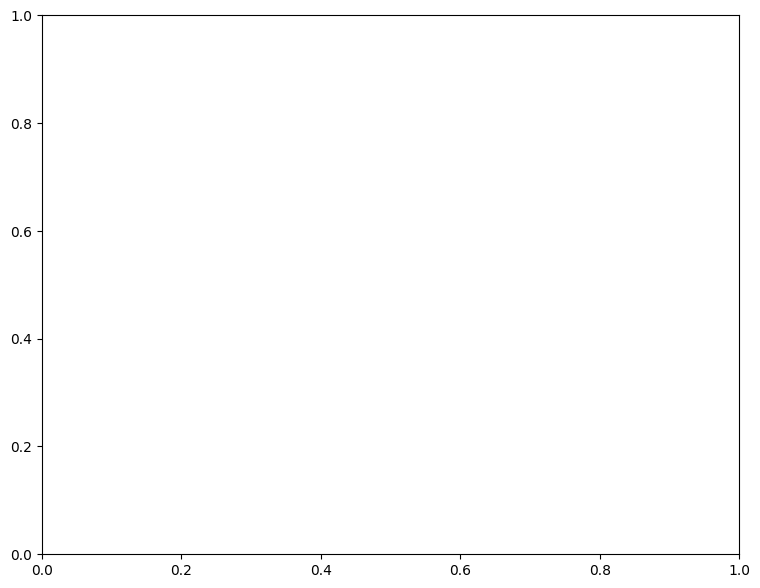

In [ ]:
rng_pca = np.random.default_rng(SEED)
idx_pca = rng_pca.choice(len(projetor.Wpc), min(5000, len(projetor.Wpc)), replace=False)

CLASSE_NOMES = {0: 'Sem rótulo', 1: 'Excitatory', 2: 'Endothelial',
                3: 'Inhibitory',  4: 'Astrocytes', 5: 'Microglia',
                6: 'Oligodendrocytes', 7: 'OPCs'}
CORES = {0: '#cccccc', 1: '#e6194b', 2: '#3cb44b', 3: '#4363d8',
         4: '#f58231', 5: '#911eb4', 6: '#42d4f4', 7: '#f032e6'}

fig_pca, ax = plt.subplots(figsize=(9, 7))
for cls in sorted(CORES):
    mask = clo[idx_pca] == cls
    if mask.any():
        ax.scatter(projetor.Wpc[idx_pca][mask, 0],
                   projetor.Wpc[idx_pca][mask, 1],
                   c=CORES[cls], label=f'{cls} — {CLASSE_NOMES[cls]}',
                   s=6, alpha=0.6, linewidths=0)
ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
ax.set_title(f'PCA — espaço SWeeP Fujita (n={len(idx_pca):,} células)')
ax.legend(markerscale=3, fontsize=9, loc='best')
plt.tight_layout(); plt.show()


#### 9. Extração de padrões por subcluster (perf35)
# 
# Para cada uma das 7 classes executa KMeans com `nc=10` clusters no espaço
# SWeeP e seleciona o vetor binário mais próximo de cada centroide como
# representante. Resulta em `7 × 10 = 70 padrões`.
# 
# ```matlab
# for ii in classes:
#     km = kmeans(Wswp[clo==ii], nc)
#     for centroide in km.centroids:
#         idx = closervects(Wswp[clo==ii], centroide, k=1)
#         perf35.append(W0[clo==ii][idx])
# ```

In [ ]:
extrator = ExtratorPadroesSubcluster(
    W0      = carregador.W0,
    labels  = clo_ref,
    classes = [1, 2, 3, 4, 5, 6, 7],
    seed    = SEED,
    nc      = 30,
    k       = 10,
)
extrator.extrair(projetor.Wswp)
perf35 = extrator.padroes
print(extrator)
print(f'perf35 shape: {perf35.shape}  (esperado: (210, 58.326)')


[ExtratorPadroesSubcluster] Classe 1: n=18865 Aplicando estratégia de clusterização...
[ExtratorPadroesSubcluster] Classe 2: n=1416 Aplicando estratégia de clusterização...
[ExtratorPadroesSubcluster] Classe 3: n=5910 Aplicando estratégia de clusterização...
[ExtratorPadroesSubcluster] Classe 4: n=2689 Aplicando estratégia de clusterização...
[ExtratorPadroesSubcluster] Classe 5: n=1735 Aplicando estratégia de clusterização...
[ExtratorPadroesSubcluster] Classe 6: n=24388 Aplicando estratégia de clusterização...
[ExtratorPadroesSubcluster] Classe 7: n=3323 Aplicando estratégia de clusterização...
[ExtratorPadroesSubcluster] Extração concluída: 210 padrões (7 classes, amostragem k=10)
ExtratorPadroesSubcluster(
  W0         = (58326, 61541)
  labels     = (58326,)
  classes    = [1, 2, 3, 4, 5, 6, 7]
  estrategia = EstrategiaKMeansFixo
  k          = 10
  seed       = 42
  padroes    = (210, 61541)
)
perf35 shape: (210, 61541)  (esperado: (210, 58.326)


In [ ]:
rede35 = ModernHopfieldNetwork(beta=50.0, n_iters=1, binary=True, threshold=0.0)
# A rede agora mapeará e armazenará apenas a versão original W0-Binária
rede35.store(perf35)
meta_eval = extrator.meta  # mapeamento padrao -> classe
print(rede35)

In [ ]:
import os

PATH_PT   = os.path.join(OUT_HOPFIELD, 'rede35.pt')
PATH_META = os.path.join(OUT_HOPFIELD, 'rede35.json')

# 1. Cria e armazena os 210 padrões na rede Hopfield
rede35 = ModernHopfieldNetwork(beta=50.0, n_iters=1, binary=True, threshold=0.0)
rede35.store(perf35)
meta_eval = extrator.meta

# 2. Salva a rede (.pt) e os metadados (.json) no disco
rede35.salvar_com_metadados(
    path_pt   = PATH_PT,
    path_meta = PATH_META,
    meta      = extrator.meta,
    classes   = [1, 2, 3, 4, 5, 6, 7],
    nc        = 30
)

print("Rede Hopfield e metadados salvos com sucesso em outputs/hopfield/!")


[ModernHopfieldNetwork] 210 padrões armazenados (61541 genes, device=cpu)
[ModernHopfieldNetwork] Rede salva em: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\hopfield\rede35_v2.pt (210 padrões)
[ModernHopfieldNetwork] Metadados salvos em: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\hopfield\rede35_v2_metadata.json (210 padrões, 61541 genes)
Rede Hopfield e metadados salvos com sucesso em outputs/hopfield/!


[ModernHopfieldNetwork] Recuperação concluída: (1000, 61541) (dtype=float32)
hopf_ts(Wswp[:1000], rede35): shape (1000, 61541)

Acurácia subclasse clo==3: 96.00%
              precision    recall  f1-score   support

           2       0.00      0.00      0.00         0
           3       1.00      0.96      0.98      1000
           4       0.00      0.00      0.00         0
           5       0.00      0.00      0.00         0
           6       0.00      0.00      0.00         0

    accuracy                           0.96      1000
   macro avg       0.20      0.19      0.20      1000
weighted avg       1.00      0.96      0.98      1000



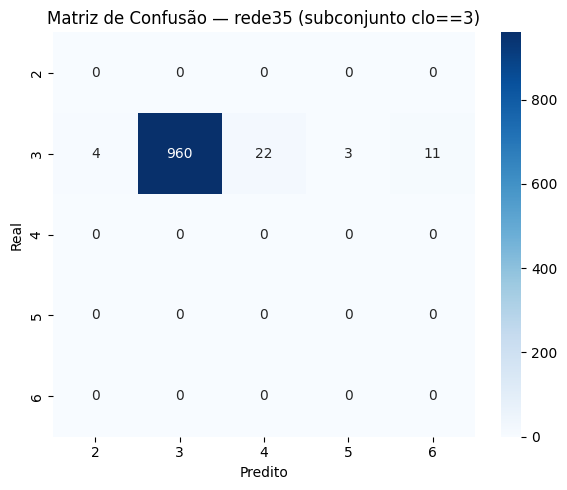

In [ ]:


NC   = 30
CLASSES_ARR = np.array([1, 2, 3, 4, 5, 6, 7])

# Agora a query é o espaço W0 Binário Original!
Wk4    = wsort(carregador.W0[clo == 3])
n_test = min(1000, Wk4.shape[0])
Wtes   = rede35.retrieve(Wk4[:n_test], batch_size=4096)
print(f'hopf_ts(Wswp[:{n_test}], rede35): shape {Wtes.shape}')

perf35_f = perf35.astype(np.float64)
Wtes_f   = Wtes.astype(np.float64)
a2 = (Wtes_f ** 2).sum(axis=1, keepdims=True)
b2 = (perf35_f ** 2).sum(axis=1, keepdims=True).T
idx_proto = (a2 + b2 - 2 * (Wtes_f @ perf35_f.T)).argmin(axis=1)
pred_sub  = CLASSES_ARR[idx_proto // NC]

acc_sub = (pred_sub == 3).mean()
print(f'\nAcurácia subclasse clo==3: {acc_sub * 100:.2f}%')


y_true_sub = np.full(n_test, 3)
labels_sub = sorted(set(y_true_sub) | set(pred_sub))
print(classification_report(y_true_sub, pred_sub, labels=labels_sub, zero_division=0))

cm_sub = confusion_matrix(y_true_sub, pred_sub, labels=labels_sub)
fig, ax = plt.subplots(figsize=(max(6, len(labels_sub)), max(5, len(labels_sub))))
sns.heatmap(cm_sub, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_sub, yticklabels=labels_sub, ax=ax)
ax.set_xlabel('Predito'); ax.set_ylabel('Real')
ax.set_title('Matriz de Confusão — rede35 (subconjunto clo==3)')
plt.tight_layout(); plt.show()


# ## 12. Auto-imputação — Fujita → Fujita
# 
# Baseline interno: a rede treinada em Fujita recebe as próprias células Fujita.
# Esperamos alta taxa de reconstrução e classificação.

In [ ]:
# 1. Recarrega o módulo com o novo suporte a matrizes esparsas
import importlib
import treinamento
importlib.reload(treinamento)
from treinamento import ModernHopfieldNetwork

# 2. Recria e armazena os padrões na rede
rede35 = ModernHopfieldNetwork(beta=30.0, n_iters=1, binary=True, threshold=0.0)
rede35.store(perf35)

# 3. Executa a auto-imputação (agora aceita matrizes esparsas em lotes de 4096)
print('=== Auto-imputação: Fujita → Fujita ===')
Wrecuperado_f = rede35.retrieve(carregador.W0, batch_size=4096)
print(f"Wrecuperado_f concluído! Shape: {Wrecuperado_f.shape}")


NameError: name 'perf35' is not defined

In [ ]:


# ==============================================================================
# 3. Auto-imputação (Fujita → Fujita)
# ==============================================================================
print('\n=== Auto-imputação: Fujita → Fujita ===')
Wrecuperado_f = rede35.retrieve(carregador.W0, batch_size=4096)
print(f"Auto-imputação concluída! Shape: {Wrecuperado_f.shape}")


[ExtratorPadroesSubcluster] Classe 1: n=18865 Aplicando estratégia de clusterização...
[ExtratorPadroesSubcluster] Classe 2: n=1416 Aplicando estratégia de clusterização...
[ExtratorPadroesSubcluster] Classe 3: n=5910 Aplicando estratégia de clusterização...
[ExtratorPadroesSubcluster] Classe 4: n=2689 Aplicando estratégia de clusterização...
[ExtratorPadroesSubcluster] Classe 5: n=1735 Aplicando estratégia de clusterização...
[ExtratorPadroesSubcluster] Classe 6: n=24388 Aplicando estratégia de clusterização...
[ExtratorPadroesSubcluster] Classe 7: n=3323 Aplicando estratégia de clusterização...
[ExtratorPadroesSubcluster] Extração concluída: 210 padrões (7 classes, amostragem k=3)
Padrões extraídos com sucesso! Shape: (210, 61541)
[ModernHopfieldNetwork] 210 padrões armazenados (61541 genes, device=cpu)
ModernHopfieldNetwork(
  beta       = 30.0
  n_iters    = 1
  binary     = True
  threshold  = 0.0
  normalize  = False
  patterns   = 210 × 61541
)

=== Auto-imputação: Fujita → Fuji

: 